# Learning Objectives

In [ ]:
# By the end of this session, students will be able to:
# 1. Load and visualize image datasets (MNIST).
# 2. Preprocess images for machine learning (grayscale, resizing, flattening).
# 3. Train a K-Nearest Neighbors (KNN) classifier on image data.
# 4. Evaluate classifier performance using accuracy and confusion matrix.
# 5. Test predictions on new images.

# Part 1 - Install Library

In [ ]:
!pip install scikit-learn matplotlib tensorflow

# Part 2 - Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.datasets import mnist

# Part 3 - Load Dataset (MNIST)

In [ ]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

# -----------------------------------------------------------------------------------
# 1. MNIST = Modified National Institute of Standards and Technology dataset.
# 2. It contains 70,000 grayscale images of handwritten digits 0–9.
#    - X_train: training images, shape (60000, 28, 28)
#    - y_train: training labels, shape (60000,)
#    - X_test: testing images, shape (10000, 28, 28)
#    - y_test: testing labels, shape (10000,)
# 3. Pixel values range from 0 (black) to 255 (white). Can be normalized later.
# 4. MNIST is widely used for teaching and benchmarking ML models like KNN.
# -----------------------------------------------------------------------------------

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


# Part 4 - Visualize Sample Images

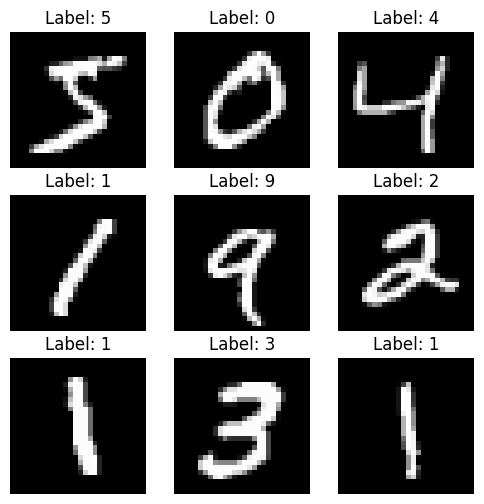

In [ ]:
# Show first 9 images
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title("Label: {}".format(y_train[i]))
    plt.axis('off')
plt.show()

# Part 5 - Simple Feature Extraction: Histogram of Intensities

In [ ]:
# Function to extract normalized histogram from an image
def extract_histogram(img, bins=125):
    hist, _ = np.histogram(img, bins=bins, range=(0,255))  # Divide pixel values into 'bins'
    hist = hist / hist.sum()  # Normalize to sum=1
    return hist

# Apply histogram extraction to all training and test images
features_train = np.array([extract_histogram(img) for img in X_train])
features_test = np.array([extract_histogram(img) for img in X_test])

print("Feature vector shape:", features_train.shape)  # (60000, 16)

Feature vector shape: (60000, 125)


# Part 6 - Train KNN Classifier

k=1, Test Accuracy: 29.17%
k=3, Test Accuracy: 29.64%
k=5, Test Accuracy: 30.70%
k=7, Test Accuracy: 31.39%
k=9, Test Accuracy: 32.09%


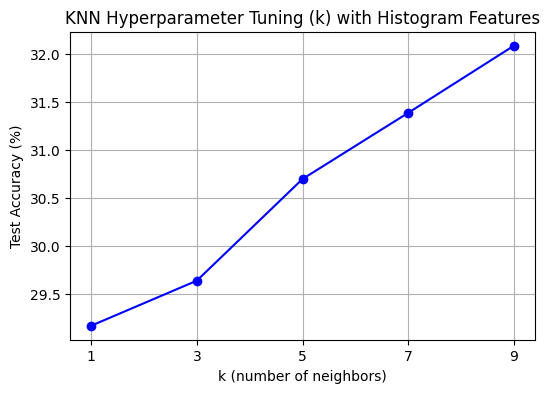

In [ ]:
# List of k values to try (odd numbers to avoid tie)
k_values = [1, 3, 5, 7, 9]
accuracies_percent = []  # store accuracy in percentage

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(features_train, y_train)  # Train on histogram features
    y_pred = knn.predict(features_test)  # Predict test set
    acc = accuracy_score(y_test, y_pred)

    acc_percent = acc * 100  # convert to percentage
    accuracies_percent.append(acc_percent)
    print(f"k={k}, Test Accuracy: {acc_percent:.2f}%")  # show 2 decimal points

# Visualize accuracy vs k
plt.figure(figsize=(6,4))
plt.plot(k_values, accuracies_percent, marker='o', color='blue')
plt.title("KNN Hyperparameter Tuning (k) with Histogram Features")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Test Accuracy (%)")
plt.xticks(k_values)  # make x-axis ticks exactly the k values
plt.grid(True)
plt.show()

# Part 7 - Evaluate Model


Best k = 9 with Test Accuracy: 32.09%



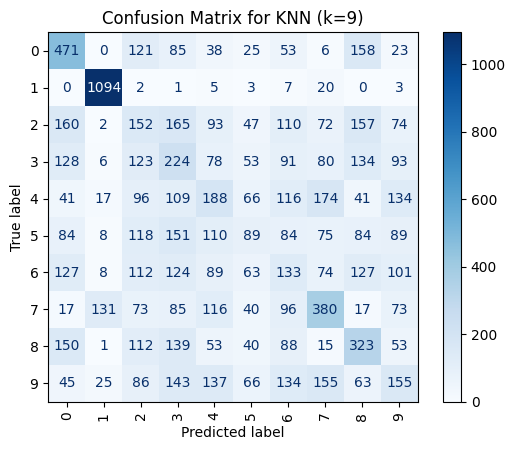

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Find the index of the best k (highest accuracy)
best_index = np.argmax(accuracies_percent)
best_k = k_values[best_index]
print(f"\nBest k = {best_k} with Test Accuracy: {accuracies_percent[best_index]:.2f}%\n")

# Train KNN with the best k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(features_train, y_train)
y_best_pred = knn_best.predict(features_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.title(f"Confusion Matrix for KNN (k={best_k})")
plt.show()

# Part 8 - Compare with Raw Pixels

Test Accuracy using raw pixels: 96.59%


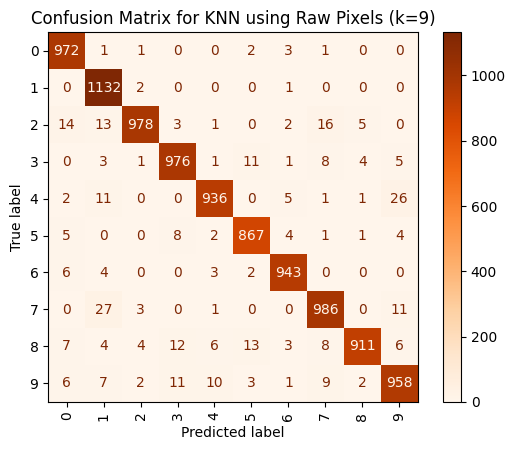

In [ ]:
# Flatten 28x28 images to 1D vectors (28*28 = 784 pixels)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Train KNN on raw pixel values
knn_raw = KNeighborsClassifier(n_neighbors=best_k)  # use the best k from previous tuning
knn_raw.fit(X_train_flat, y_train)

# Predict test set using raw pixels
y_pred_raw = knn_raw.predict(X_test_flat)

# Calculate accuracy in percentage
accuracy_raw_percent = accuracy_score(y_test, y_pred_raw) * 100
print(f"Test Accuracy using raw pixels: {accuracy_raw_percent:.2f}%")

# Optional: confusion matrix for raw pixels
cm_raw = confusion_matrix(y_test, y_pred_raw)
disp_raw = ConfusionMatrixDisplay(confusion_matrix=cm_raw)
disp_raw.plot(cmap=plt.cm.Oranges, xticks_rotation='vertical')
plt.title(f"Confusion Matrix for KNN using Raw Pixels (k={best_k})")
plt.show()

# Part 9 - Predict Single Image Example

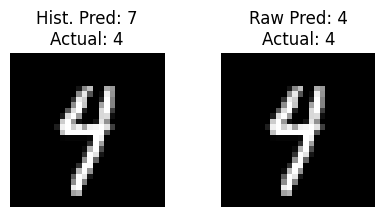

In [ ]:
# Choose an index from the test set
index = 4567

# --- Using histogram features ---
test_img_hist = features_test[index].reshape(1, -1)  # histogram feature vector
prediction_hist = knn_best.predict(test_img_hist)

plt.figure(figsize=(5,2))
plt.subplot(1,2,1)
plt.imshow(X_test[index], cmap='gray')
plt.title(f"Hist. Pred: {prediction_hist[0]}\nActual: {y_test[index]}")
plt.axis('off')

# --- Using raw pixels ---
test_img_raw = X_test_flat[index].reshape(1, -1)  # raw pixel vector
prediction_raw = knn_raw.predict(test_img_raw)

plt.subplot(1,2,2)
plt.imshow(X_test[index], cmap='gray')
plt.title(f"Raw Pred: {prediction_raw[0]}\nActual: {y_test[index]}")
plt.axis('off')

plt.show()

# Part 10 - Dicussion

### 1. Feature extraction vs raw pixels
- **Histogram features:** simple, low-dimensional, easy to compute, but lose **spatial information** → low accuracy (~32%).
- **Raw pixels:** preserve all spatial patterns → high accuracy (~96%), but high-dimensional.
- **Lesson:** Feature selection/extraction must capture **meaningful structure** for ML.

### 2. Effect of K in KNN
- Small `k` (e.g., 1) → sensitive to noise, may overfit.
- Large `k` → smoother predictions, may underfit.
- Best `k` balances bias-variance tradeoff (hyperparameter tuning helps find it).

### 3. Confusion matrix analysis
- Misclassifications often occur for digits with **similar shapes**, e.g., “4” vs “9” or “1” vs “7”.
- Helps identify which digits need better feature representation.

### 4. Limitations of simple histogram features
- Cannot distinguish shape or orientation differences.
- Good for teaching **feature concept**, but not robust for real datasets.

### 5. Practical insights for DIP & ML
- Feature engineering is a key step in **DIP → ML pipeline**.
- For complex images, using **edges, textures, shapes**, or **CNNs** is recommended.
- Always compare **different features** and visualize results to understand model behavior.

### 6. Classroom activity suggestion
- Experiment with:
  - Increasing histogram bins (e.g., 32 or 64)
  - Adding simple edge features (Canny edge counts)
  - Using subsets of MNIST for faster experimentation
- Observe how features affect accuracy and confusion matrix patterns.